In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Loading the Dataset and concatenating all the dataframes

In [ ]:
data1 = pd.read_csv('Enr_data1.csv')
data2 = pd.read_csv('Enr_data2.csv')
data3 = pd.read_csv('Enr_data3.csv')
data=pd.concat([data1,data2,data3],ignore_index = True)
data.head(5)

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,02-03-2025,Meghalaya,East Khasi Hills,793121,11,61,37
1,09-03-2025,Karnataka,Bengaluru Urban,560043,14,33,39
2,09-03-2025,Uttar Pradesh,Kanpur Nagar,208001,29,82,12
3,09-03-2025,Uttar Pradesh,Aligarh,202133,62,29,15
4,09-03-2025,Karnataka,Bengaluru Urban,560016,14,16,21


Understanding the Dataset.


In [ ]:
print(data.shape)
print('\n')
print(data.describe())
print('\n')
print(data.info())

(1006029, 7)


            pincode       age_0_5      age_5_17  age_18_greater
count  1.006029e+06  1.006029e+06  1.006029e+06    1.006029e+06
mean   5.186415e+05  3.525709e+00  1.710074e+00    1.673441e-01
std    2.056360e+05  1.753851e+01  1.436963e+01    3.220525e+00
min    1.000000e+05  0.000000e+00  0.000000e+00    0.000000e+00
25%    3.636410e+05  1.000000e+00  0.000000e+00    0.000000e+00
50%    5.174170e+05  2.000000e+00  0.000000e+00    0.000000e+00
75%    7.001040e+05  3.000000e+00  1.000000e+00    0.000000e+00
max    8.554560e+05  2.688000e+03  1.812000e+03    8.550000e+02


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006029 entries, 0 to 1006028
Data columns (total 7 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   date            1006029 non-null  object
 1   state           1006029 non-null  object
 2   district        1006029 non-null  object
 3   pincode         1006029 non-null  int64 
 4   age_0_5       

**This Data Contains**

The dataset is about the enrollment of Aadhar of different Age_groups on different date in specific pincode of specified District in Different States.

*   The Dataset has around 1 Million+ records from different Pincodes of different Districts of different States.

*   This Dataset has 7 Columns in total consisting of Date, District, State, Pincode, 3 Columns having different age_groups who enrolled for Aadhar.



Date column has datatype **Object**. So for effective Date wise analysis we need to convert Date into date type.

In [ ]:
data['date'] = pd.to_datetime(data['date'], format = "%d-%m-%Y")

In [ ]:
data['date'].dtype

dtype('<M8[ns]')

In [ ]:
data.isnull().sum()

,0
date,0
state,0
district,0
pincode,0
age_0_5,0
age_5_17,0
age_18_greater,0


The Dataset doesn't have any Null Values

In [ ]:
data.iloc[:,1:4].nunique()

,0
state,55
district,985
pincode,19463


Logically India has 28 States and 8 UT. So there must be duplicates of State and about 900 District along with sub district in terms of Spelling. So It should be detected and corrected.

In [ ]:
data.iloc[:,1].unique()

array(['Meghalaya', 'Karnataka', 'Uttar Pradesh', 'Bihar', 'Maharashtra',
       'Haryana', 'Rajasthan', 'Punjab', 'Delhi', 'Madhya Pradesh',
       'West Bengal', 'Assam', 'Uttarakhand', 'Gujarat', 'Andhra Pradesh',
       'Tamil Nadu', 'Chhattisgarh', 'Jharkhand', 'Nagaland', 'Manipur',
       'Telangana', 'Tripura', 'Mizoram', 'Jammu and Kashmir',
       'Chandigarh', 'Sikkim', 'Odisha', 'Kerala',
       'The Dadra And Nagar Haveli And Daman And Diu',
       'Arunachal Pradesh', 'Himachal Pradesh', 'Goa',
       'Jammu And Kashmir', 'Dadra and Nagar Haveli and Daman and Diu',
       'Ladakh', 'Andaman and Nicobar Islands', 'Orissa', 'Pondicherry',
       'Puducherry', 'Lakshadweep', 'Andaman & Nicobar Islands',
       'Dadra & Nagar Haveli', 'Dadra and Nagar Haveli', 'Daman and Diu',
       'WEST BENGAL', 'Jammu & Kashmir', 'West  Bengal', '100000',
       'Daman & Diu', 'West Bangal', 'Westbengal', 'West bengal',
       'andhra pradesh', 'ODISHA', 'WESTBENGAL'], dtype=object)

In [ ]:
change = {'The Dadra And Nagar Haveli And Daman And Diu':'Dadra and Nagar Haveli and Daman and Diu',
          'Dadra & Nagar Haveli':'Dadra and Nagar Haveli and Daman and Diu',
          'Dadra and Nagar Haveli':'Dadra and Nagar Haveli and Daman and Diu',
          'Daman and Diu':'Dadra and Nagar Haveli and Daman and Diu',
          'Daman & Diu':'Dadra and Nagar Haveli and Daman and Diu',

          'WEST BENGAL':'West Bengal',
          'West  Bengal':'West Bengal',
          'Westbengal':'West Bengal',
          'West bengal':'West Bengal',
          'WESTBENGAL':'West Bengal',
          'West Bangal':'West Bengal',

          'Jammu And Kashmir':'Jammu and Kashmir',
          'Jammu & Kashmir':'Jammu and Kashmir',

          'ODISHA':'Odisha',
          'Orissa':'Odisha',

          'Andaman & Nicobar Islands':'Andaman and Nicobar Islands',

          'andhra pradesh':'Andhra Pradesh',

          'Pondicherry':'Puducherry'
          }


data['state'] = data.iloc[:,1].replace(change)

In [ ]:
(data['state'] == '100000').sum()

np.int64(22)

In [ ]:
data[data['state'] == '100000']

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
23108,2025-09-02,100000,100000,100000,0,0,3
46946,2025-09-03,100000,100000,100000,0,0,1
97816,2025-09-08,100000,100000,100000,0,0,1
115798,2025-09-09,100000,100000,100000,0,0,1
153156,2025-09-11,100000,100000,100000,0,0,2
160195,2025-09-12,100000,100000,100000,0,0,2
261778,2025-09-19,100000,100000,100000,0,0,1
272731,2025-09-20,100000,100000,100000,0,0,1
470934,2025-10-24,100000,100000,100000,0,1,0
762744,2025-11-15,100000,100000,100000,0,0,3


In [ ]:
data['district'].unique()

array(['East Khasi Hills', 'Bengaluru Urban', 'Kanpur Nagar', 'Aligarh',
       'Sitamarhi', 'Bahraich', 'Firozabad', 'Purbi Champaran',
       'Maharajganj', 'Aurangabad', 'Ghaziabad', 'Faridabad', 'Madhubani',
       'Sikar', 'Bhagalpur', 'Amritsar', 'Gurugram',
       'Gautam Buddha Nagar', 'West Delhi', 'Bhind', 'Gwalior', 'Katni',
       'Coochbehar', 'Lucknow', 'Dinajpur Uttar', 'Marigaon', 'Kokrajhar',
       'Agra', 'Haridwar', 'Nagaon', 'Parbhani', 'West Khasi Hills',
       'North West Delhi', 'West Jaintia Hills', 'Unnao', 'Saharanpur',
       'Dibrugarh', 'Udalguri', 'Chirang', 'Kamrup', 'Dhubri', 'Jaunpur',
       'Thane', 'Dhemaji', 'Banas Kantha', 'Tinsukia', 'Spsr Nellore',
       'Barpeta', 'Sonitpur', 'Baksa', 'Ludhiana', 'Patan', 'Kanchipuram',
       'Patna', 'Lakhimpur', 'Bongaigaon', 'Vadodara', 'Nainital',
       'Dehradun', 'Hojai', 'Dohad', 'Morbi', 'Raipur', 'Gorakhpur',
       'Bulandshahr', 'Mathura', 'Pashchim Champaran', 'Bijapur',
       'Deoghar', 'Muzaf

In [ ]:
change2 = {

    'Coochbehar': 'Cooch Behar',
    'Koch Bihar': 'Cooch Behar',
    'Barddhaman': 'Bardhaman',
    'Burdwan': 'Bardhaman',
    'Medinipur': 'Medinipur',
    'Midnapore': 'Medinipur',
    'West Medinipur': 'Medinipur West',
    'Dinajpur Uttar': 'Uttar Dinajpur',
    'Dinajpur Dakshin': 'Dakshin Dinajpur',
    '24 Paraganas North': 'North 24 Parganas',
    'North Twenty Four Parganas': 'North 24 Parganas',
    '24 Paraganas South': 'South 24 Parganas',
    'South Twenty Four Parganas': 'South 24 Parganas',


    'Purbi Champaran': 'East Champaran',
    'Pashchim Champaran': 'West Champaran',
    'Samstipur': 'Samastipur',
    'Sheikpura': 'Sheikhpura',
    'Purnea': 'Purnia',


    'Bangalore': 'Bengaluru',
    'Bangalore Rural': 'Bengaluru Rural',
    'Bangalore Urban': 'Bengaluru Urban',
    'Belgaum': 'Belagavi',
    'Bellary': 'Ballari',
    'Gulbarga': 'Kalaburagi',
    'Mysore': 'Mysuru',
    'Shimoga': 'Shivamogga',
    'Tumkur': 'Tumakuru',
    'Chikmagalur': 'Chikkamagaluru',


    'Mahabub Nagar': 'Mahbubnagar',
    'Rangareddi': 'Ranga Reddy',
    'K.V. Rangareddy': 'Ranga Reddy',
    'Nellore': 'Sri Potti Sriramulu Nellore',
    'Warangal (urban)': 'Warangal Urban',
    'Medchal-malkajgiri': 'Medchal Malkajgiri',
    'Medchal−malkajgiri': 'Medchal Malkajgiri',


    'Ahmed Nagar': 'Ahmednagar',
    'Ahmadnagar': 'Ahmednagar',
    'Aurangabad': 'Chhatrapati Sambhajinagar',
    'Bid': 'Beed',
    'Buldana': 'Buldhana',
    'Gondiya': 'Gondiya',

    'Allahabad': 'Prayagraj',
    'Faizabad': 'Ayodhya',


    'HOOGHLY': 'Hooghly',
    'hooghly': 'Hooghly',
    'Hooghiy': 'Hooghly',
    'KOLKATA': 'Kolkata',
    'HOWRAH': 'Howrah',
    'Haora': 'Howrah',
    'Hawrah': 'Howrah',
    'NADIA': 'Nadia',
    'nadia': 'Nadia',
    'MALDA': 'Malda',
    'JAJPUR': 'Jajpur',
    'jajpur': 'Jajpur',
    'ANGUL': 'Angul',
    'ANUGUL': 'Angul'
}


In [ ]:
data['district'] = data['district'].replace(change2)

In [ ]:
data['district'].unique()

array(['East Khasi Hills', 'Bengaluru Urban', 'Kanpur Nagar', 'Aligarh',
       'Sitamarhi', 'Bahraich', 'Firozabad', 'East Champaran',
       'Maharajganj', 'Chhatrapati Sambhajinagar', 'Ghaziabad',
       'Faridabad', 'Madhubani', 'Sikar', 'Bhagalpur', 'Amritsar',
       'Gurugram', 'Gautam Buddha Nagar', 'West Delhi', 'Bhind',
       'Gwalior', 'Katni', 'Cooch Behar', 'Lucknow', 'Uttar Dinajpur',
       'Marigaon', 'Kokrajhar', 'Agra', 'Haridwar', 'Nagaon', 'Parbhani',
       'West Khasi Hills', 'North West Delhi', 'West Jaintia Hills',
       'Unnao', 'Saharanpur', 'Dibrugarh', 'Udalguri', 'Chirang',
       'Kamrup', 'Dhubri', 'Jaunpur', 'Thane', 'Dhemaji', 'Banas Kantha',
       'Tinsukia', 'Spsr Nellore', 'Barpeta', 'Sonitpur', 'Baksa',
       'Ludhiana', 'Patan', 'Kanchipuram', 'Patna', 'Lakhimpur',
       'Bongaigaon', 'Vadodara', 'Nainital', 'Dehradun', 'Hojai', 'Dohad',
       'Morbi', 'Raipur', 'Gorakhpur', 'Bulandshahr', 'Mathura',
       'West Champaran', 'Bijapur', 'Deogh

In [ ]:
change3 = {


    'Deeg\xa0': 'Deeg',
    'North East   *': 'North East',
    'Namakkal   *': 'Namakkal',



    'Chamarajanagar *': 'Chamarajanagar',
    'Harda *': 'Harda',
    'Washim *': 'Washim',
    'Udupi *': 'Udupi',
    'Hingoli *': 'Hingoli',
    'Gadag *': 'Gadag',
    'Bagalkot *': 'Bagalkot',
    'Dhalai  *': 'Dhalai',
    'Aurangabad(BH)': 'Aurangabad',
    'Leh (ladakh)': 'Leh',
    'Bijapur(KAR)': 'Bijapur',
    'Dadra & Nagar Haveli': 'Dadra and Nagar Haveli',



    'rangareddi': 'Rangareddy',
    'chittoor': 'Chittoor',
    'Anugal': 'Anugul',



    'Medchal?malkajgiri': 'Medchal Malkajgiri',
    'Mahrajganj': 'Maharajganj',


    'Tiruvarur': 'Thiruvarur',
    'South 24 parganas': 'South 24 Parganas'
}

data['district'] = data['district'].replace(change3)

In [ ]:
data.iloc[:,1:4].nunique()

,0
state,37
district,912
pincode,19463


In [ ]:
data.sample(5)

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
266543,2025-09-20,Andhra Pradesh,Visakhapatnam,531162,3,0,0
958103,2025-12-27,Telangana,Mancherial,504205,2,0,0
546110,2025-10-30,Uttar Pradesh,Lucknow,226016,11,15,0
891826,2025-12-22,Andhra Pradesh,Adilabad,504103,3,0,0
878887,2025-12-22,Andhra Pradesh,Chittoor,517001,3,0,0


After Preprocessing of the Dataset:

1. We have seen there is Data for **36 Different States and Union Territory** along with some data whose State is not Mentioned.

2. The Data has been taken from **912 different Districts and Sub-Districts**

3. The Data is come from **19463 Different** Pincodes

Means we can say in a consolidated form that this Data after correction has records of **36 States, 900+ Districts and 19000+ Pincodes**



In [ ]:
data.duplicated().sum()

np.int64(26487)

There are **26000+ Duplicates records** in the Dataset, we have to see it exactly and Drop it.

In [ ]:
dup = data[data.duplicated(keep=False)]
dup.sort_values(by=data.columns.tolist()).head(20)

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
12135,2025-09-01,Andaman and Nicobar Islands,South Andaman,744103,1,0,0
15265,2025-09-01,Andaman and Nicobar Islands,South Andaman,744103,1,0,0
8138,2025-09-01,Andaman and Nicobar Islands,South Andaman,744207,1,0,0
12136,2025-09-01,Andaman and Nicobar Islands,South Andaman,744207,1,0,0
10638,2025-09-01,Andhra Pradesh,Sri Potti Sriramulu Nellore,524003,2,0,0
13845,2025-09-01,Andhra Pradesh,Sri Potti Sriramulu Nellore,524003,2,0,0
6571,2025-09-01,Andhra Pradesh,Sri Potti Sriramulu Nellore,524323,0,1,0
13848,2025-09-01,Andhra Pradesh,Sri Potti Sriramulu Nellore,524323,0,1,0
13850,2025-09-01,Andhra Pradesh,Sri Potti Sriramulu Nellore,524407,1,0,0
17890,2025-09-01,Andhra Pradesh,Sri Potti Sriramulu Nellore,524407,1,0,0


In [ ]:
data = data.drop_duplicates(keep = 'first')

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.shape

(979542, 7)

In [ ]:
print(data.sort_values(by = 'date' , ascending = False)['date'].head(1))
print(data.sort_values(by = 'date' , ascending = True)['date'].head(1))

1006028   2025-12-31
Name: date, dtype: datetime64[ns]
0   2025-03-02
Name: date, dtype: datetime64[ns]


**ABOUT DATA**

**This Data Contains :**

The dataset is about the enrollment of Aadhar of different Age_groups on different date in specific pincode of specified District in Different States.

*   The Dataset has around 1 Million+ records from different Pincodes of different Districts of different States.

*   This Dataset has 7 Columns in total consisting of Date, District, State, Pincode, 3 Columns having different age_groups who enrolled for Aadhar.

*   Data of Enrollment is available from 2nd March to 31st December of the Year 2025 during which about 9 Lakhs 70 Thousand enrollment has been done all over India.


Exploratory Data Analysis(EDA) :

In [ ]:
state_name = data['state'].unique()
state_name

array(['Meghalaya', 'Karnataka', 'Uttar Pradesh', 'Bihar', 'Maharashtra',
       'Haryana', 'Rajasthan', 'Punjab', 'Delhi', 'Madhya Pradesh',
       'West Bengal', 'Assam', 'Uttarakhand', 'Gujarat', 'Andhra Pradesh',
       'Tamil Nadu', 'Chhattisgarh', 'Jharkhand', 'Nagaland', 'Manipur',
       'Telangana', 'Tripura', 'Mizoram', 'Jammu and Kashmir',
       'Chandigarh', 'Sikkim', 'Odisha', 'Kerala',
       'Dadra and Nagar Haveli and Daman and Diu', 'Arunachal Pradesh',
       'Himachal Pradesh', 'Goa', 'Ladakh', 'Andaman and Nicobar Islands',
       'Puducherry', 'Lakshadweep', '100000'], dtype=object)

In [ ]:
data.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,2025-03-02,Meghalaya,East Khasi Hills,793121,11,61,37
1,2025-03-09,Karnataka,Bengaluru Urban,560043,14,33,39
2,2025-03-09,Uttar Pradesh,Kanpur Nagar,208001,29,82,12
3,2025-03-09,Uttar Pradesh,Aligarh,202133,62,29,15
4,2025-03-09,Karnataka,Bengaluru Urban,560016,14,16,21


In [ ]:
data['Total_Enrollment'] = data['age_0_5'] + data['age_5_17'] + data['age_18_greater']
data.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,Total_Enrollment
0,2025-03-02,Meghalaya,East Khasi Hills,793121,11,61,37,109
1,2025-03-09,Karnataka,Bengaluru Urban,560043,14,33,39,86
2,2025-03-09,Uttar Pradesh,Kanpur Nagar,208001,29,82,12,123
3,2025-03-09,Uttar Pradesh,Aligarh,202133,62,29,15,106
4,2025-03-09,Karnataka,Bengaluru Urban,560016,14,16,21,51


In [ ]:
data.sort_values(by = 'date').head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,Total_Enrollment
0,2025-03-02,Meghalaya,East Khasi Hills,793121,11,61,37,109
32,2025-03-09,West Bengal,Uttar Dinajpur,733129,26,18,27,71
31,2025-03-09,Uttar Pradesh,Lucknow,226003,23,102,17,142
30,2025-03-09,West Bengal,Cooch Behar,736135,19,12,19,50
29,2025-03-09,Bihar,East Champaran,845304,18,72,12,102


In [ ]:
data['day'] = data['date'].dt.day_name()
data['month'] = data['date'].dt.month_name()
data.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,Total_Enrollment,day,month
0,2025-03-02,Meghalaya,East Khasi Hills,793121,11,61,37,109,Sunday,March
1,2025-03-09,Karnataka,Bengaluru Urban,560043,14,33,39,86,Sunday,March
2,2025-03-09,Uttar Pradesh,Kanpur Nagar,208001,29,82,12,123,Sunday,March
3,2025-03-09,Uttar Pradesh,Aligarh,202133,62,29,15,106,Sunday,March
4,2025-03-09,Karnataka,Bengaluru Urban,560016,14,16,21,51,Sunday,March


In [ ]:
data[data['state'] == '100000']['Total_Enrollment'].sum()


np.int64(214)

In [ ]:
Total_Enroll = pd.Series(0,index = state_name)
for i in state_name:
  Total_Enroll[i] = data[data['state'] == i]['Total_Enrollment'].sum()

print(Total_Enroll.sort_values(ascending= False))

Uttar Pradesh                               1002487
Bihar                                        593741
Madhya Pradesh                               487887
West Bengal                                  368451
Maharashtra                                  363269
Rajasthan                                    340591
Gujarat                                      275042
Assam                                        225359
Karnataka                                    216711
Tamil Nadu                                   215710
Jharkhand                                    153612
Telangana                                    128923
Andhra Pradesh                               124127
Odisha                                       119985
Meghalaya                                    109239
Chhattisgarh                                  99773
Haryana                                       95085
Delhi                                         92836
Punjab                                        75773
Kerala      

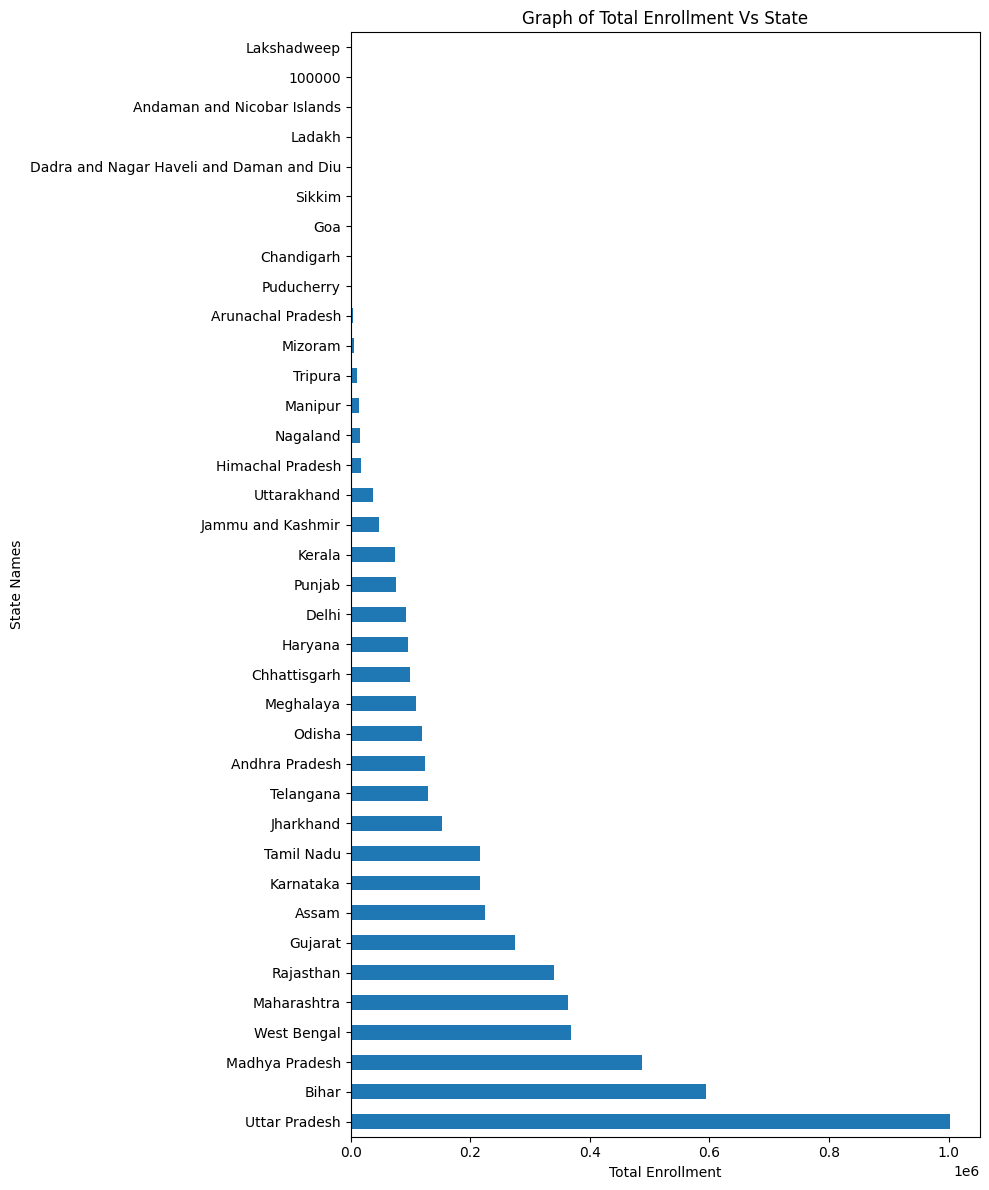

In [ ]:
plt.figure(figsize=(10, 12))
Total_Enroll.sort_values(ascending= False).plot(kind = 'barh')
plt.title('Graph of Total Enrollment Vs State')
plt.xlabel('Total Enrollment')
plt.ylabel('State Names')
plt.tight_layout()
plt.show()

Total Enrollment in Months:

In [ ]:
monthly_state = data.groupby(['state','month'])['Total_Enrollment'].sum().reset_index()
print(monthly_state.head())
print(monthly_state.shape)

                         state      month  Total_Enrollment
0                       100000   December               190
1                       100000   November                11
2                       100000    October                 1
3                       100000  September                12
4  Andaman and Nicobar Islands   December               123
(270, 3)


In [ ]:
monthly_state = monthly_state.sort_values(['state','month'])
monthly_state.head()

,state,month,Total_Enrollment
0,100000,December,190
1,100000,November,11
2,100000,October,1
3,100000,September,12
4,Andaman and Nicobar Islands,December,123


In [ ]:
monthly_state['monthly_change'] = (
    monthly_state.groupby('state')['Total_Enrollment']
    .diff()
)
monthly_state.head()

NameError: name 'monthly_state' is not defined

In [ ]:
stats = monthly_state.groupby('state')['monthly_change'].agg(['mean', 'std'])

monthly_state = monthly_state.join(stats, on='state')

monthly_state['is_surge'] = (
    monthly_state['monthly_change'] >
    monthly_state['mean'] + 2 * monthly_state['std']
)


In [ ]:
monthly_state[monthly_state['is_surge'] == True]

,state,month,Total_Enrollment,monthly_change,mean,std,is_surge


Here, From the Analysis We find that the data is behaving in Normal Distribution and there is no Anamolies in the state wise Total Enrollment

In [ ]:
monthly_state = data.groupby(['state','month'])['age_18_greater'].sum().reset_index()
monthly_state = monthly_state.sort_values(['state','month'])

monthly_state['monthly_change'] = (
    monthly_state.groupby('state')['age_18_greater'].diff())

stats = monthly_state.groupby('state')['monthly_change'].agg(['mean', 'std'])

monthly_state = monthly_state.join(stats, on='state')

monthly_state['is_surge'] = (
    monthly_state['monthly_change'] >
    monthly_state['mean'] + 2 * monthly_state['std']
)



monthly_state[monthly_state['is_surge'] == True]

,state,month,age_18_greater,monthly_change,mean,std,is_surge
156,Manipur,May,55,42.0,0.857143,18.818684,True
262,West Bengal,December,3590,3209.0,94.125000,1540.697100,True


On Further investigation,

*  We find that the **AADHAR ENROLLMENT** in Manipur in the Month of May spiked abruptly as compared to its Previous Month that is March. This is most likely due to *APAAR ID* generation order by govt.

*  We also find similar abrupt increment in the data for enrollment in West Bengal in the Month of December. This will be Most likely due to SIR Campaign by Govt. of India, Duare Sarkar scheme in winter of WB govt.

In [ ]:
data1 = data.groupby(['month','state'])['age_18_greater'].sum().reset_index()
data2 = data1[data1['state'] == 'West Bengal']
data2.sort_values(by = 'month').tail(2)

,month,state,age_18_greater
232,October,West Bengal,184
269,September,West Bengal,1134


In [ ]:
data1 = data.groupby(['month','state'])['age_18_greater'].sum().reset_index()
data2 = data1[data1['state'] == 'Manipur']
data2[(data2['month'] == 'April') | (data2['month'] == 'May')]

,month,state,age_18_greater
12,April,Manipur,26
148,May,Manipur,55


On Further investigation,

*  We find that the **AADHAR ENROLLMENT** in Manipur in the Month of May spiked abruptly as compared to its Previous Month that is March. This is most likely due to *APAAR ID* generation order by govt.

*  We also find similar abrupt increment in the data for enrollment in West Bengal in the Month of December. This will be Most likely due to SIR Campaign by Govt. of India, Duare Sarkar scheme in winter of WB govt.

In [ ]:
month_name = data['month'].unique()
Total_Enroll_Mont = pd.Series(0, index = month_name)
for i in month_name:
  Total_Enroll_Mont[i] = data[data['month'] == i]['Total_Enrollment'].sum()
print(Total_Enroll_Mont.sort_values(ascending=False))

September    1474204
November     1051434
October       778619
December      732506
July          616868
April         257438
June          215734
May           183616
March          16582
dtype: int64


In [ ]:
plt.figure(figsize=(10, 12))
Total_Enroll_Mont.sort_values(ascending= False).plot(kind = 'barh')
plt.title('Graph of Total Enrollment in Month Vs Month Name')
plt.xlabel('Total Enrollment in Month')
plt.ylabel('Month Name')
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [ ]:
Day_Name = data['day'].unique()
Total_Enroll_Day = pd.Series(0, index = Day_Name)
for i in Day_Name:
  Total_Enroll_Day[i] = data[data['day'] == i]['Total_Enrollment'].sum()
print(Total_Enroll_Day.sort_values(ascending=False))

Tuesday      1410725
Monday        799547
Wednesday     740364
Thursday      716612
Sunday        607196
Friday        545440
Saturday      507117
dtype: int64


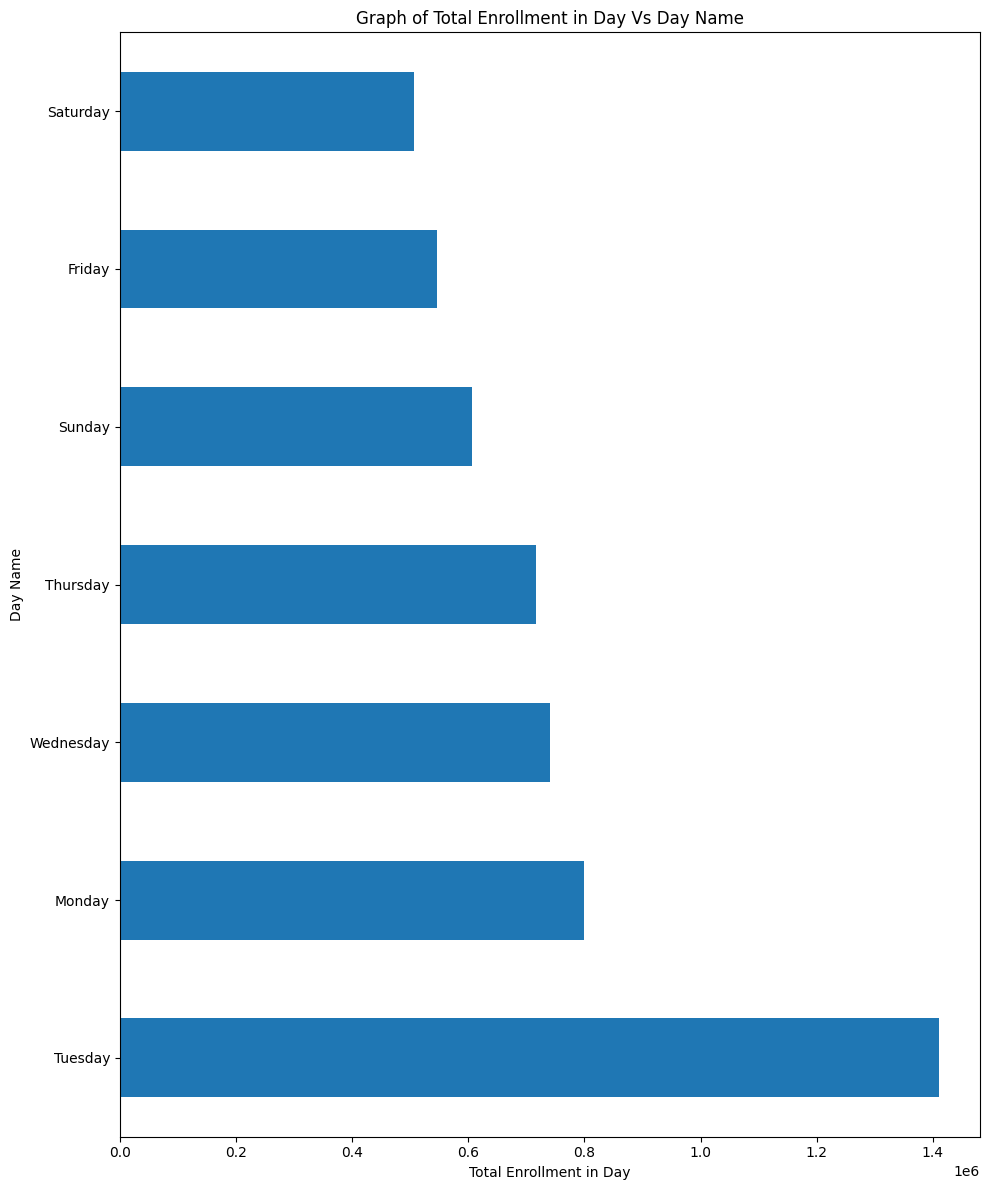

In [ ]:
plt.figure(figsize=(10,12))
Total_Enroll_Day.sort_values(ascending= False).plot(kind = 'barh')
plt.title('Graph of Total Enrollment in Day Vs Day Name')
plt.xlabel('Total Enrollment in Day')
plt.ylabel('Day Name')
plt.tight_layout()
plt.show()

In [ ]:
for i in state_name:
  print(f'State {i} :')
  print(data[data['state'] == i].groupby('district')['Total_Enrollment'].sum().sort_values(ascending = False).head(1))
  print(data[data['state'] == i].groupby('district')['Total_Enrollment'].sum().sort_values(ascending = True).head(1))
  print('\n')

State Meghalaya :
district
East Khasi Hills    28656
Name: Total_Enrollment, dtype: int64
district
Jaintia Hills    4
Name: Total_Enrollment, dtype: int64


State Karnataka :
district
Bengaluru    36975
Name: Total_Enrollment, dtype: int64
district
Haveri *    116
Name: Total_Enrollment, dtype: int64


State Uttar Pradesh :
district
Bahraich    38897
Name: Total_Enrollment, dtype: int64
district
Bagpat    1
Name: Total_Enrollment, dtype: int64


State Bihar :
district
West Champaran    46271
Name: Total_Enrollment, dtype: int64
district
Aurangabad    8
Name: Total_Enrollment, dtype: int64


State Maharashtra :
district
Thane    43142
Name: Total_Enrollment, dtype: int64
district
Ahilyanagar    12
Name: Total_Enrollment, dtype: int64


State Haryana :
district
Faridabad    15781
Name: Total_Enrollment, dtype: int64
district
Jhajjar *    1
Name: Total_Enrollment, dtype: int64


State Rajasthan :
district
Jaipur    30341
Name: Total_Enrollment, dtype: int64
district
Balotra    1
Name: Tot

pincode
244001    15124
400035        1
Name: Total_Enrollment, dtype: int64


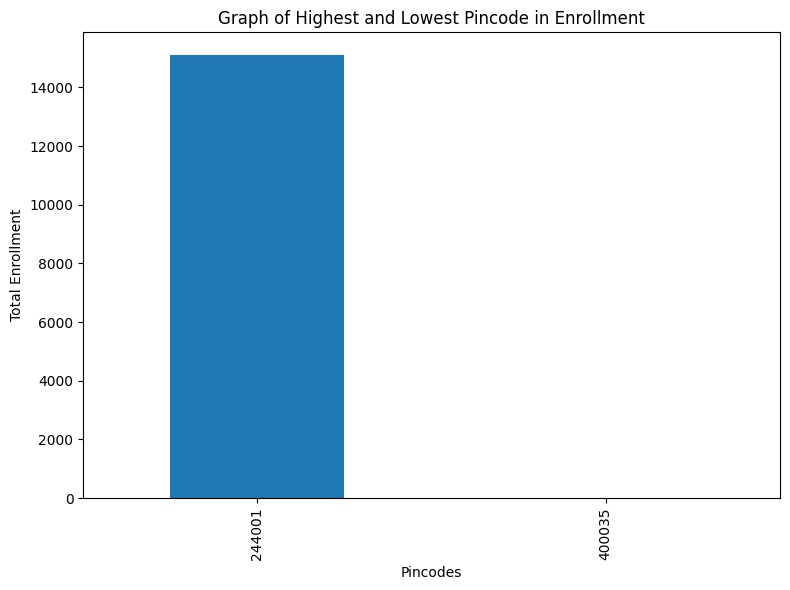

In [ ]:
pin_com = (data.groupby('pincode')['Total_Enrollment'].sum().sort_values(ascending= False))
Highest_com = pin_com.head(1)
Lowest_com = pin_com.tail(1)
pin_gra = pd.concat([Highest_com,Lowest_com])

print(pin_gra)

plt.figure(figsize=(8,6))
pin_gra.plot(kind = 'bar')
plt.title('Graph of Highest and Lowest Pincode in Enrollment')
plt.xlabel('Pincodes')
plt.ylabel('Total Enrollment')
plt.tight_layout()
plt.show()

In [ ]:
## State and District of Highest Enrollment Pincode
data[data['pincode'] == Highest_com.index[0]][['state','district','pincode']].head(1)

,state,district,pincode
878,Uttar Pradesh,Moradabad,244001


In [ ]:
## State and District of Lowest Enrollment Pincode
data[data['pincode'] == Lowest_com.index[0]][['state','district','pincode']].head(1)

,state,district,pincode
745570,Maharashtra,Mumbai City,400035


In [ ]:
data[["age_0_5","age_5_17","age_18_greater"]].sum()

,0
age_0_5,3469987
age_5_17,1690552
age_18_greater,166462


In [ ]:
data.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,Total_Enrollment,day,month
0,2025-03-02,Meghalaya,East Khasi Hills,793121,11,61,37,109,Sunday,March
1,2025-03-09,Karnataka,Bengaluru Urban,560043,14,33,39,86,Sunday,March
2,2025-03-09,Uttar Pradesh,Kanpur Nagar,208001,29,82,12,123,Sunday,March
3,2025-03-09,Uttar Pradesh,Aligarh,202133,62,29,15,106,Sunday,March
4,2025-03-09,Karnataka,Bengaluru Urban,560016,14,16,21,51,Sunday,March


In [ ]:
data[data['Total_Enrollment'] == 0]

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,Total_Enrollment,day,month


In [ ]:
states = []
enroll_less5 = []
percentages = []

for i in state_name:
    val = data[data['state'] == i]['age_0_5'].sum()
    perct = (val / Total_Enroll[i]) * 100

    states.append(i)
    enroll_less5.append(val)
    percentages.append(perct)

Age_less5 = pd.DataFrame({
    'State_Name': states,
    'Enrollment_less5': enroll_less5,
    'Percentage': percentages
})
print('According to Percentage of Enrollment of less than 5 Yrs in States Ranking is :')
print('\n')
print(Age_less5.sort_values(by='Percentage', ascending=False))
print('\n')
print('According to Number of Enrollment of less than 5 Yrs in States Ranking is :')
print('\n')
print(Age_less5.sort_values(by='Enrollment_less5', ascending = False))


According to Percentage of Enrollment of less than 5 Yrs in States Ranking is :


                                  State_Name  Enrollment_less5  Percentage
30                          Himachal Pradesh             16081   95.103199
35                               Lakshadweep               188   94.472362
33               Andaman and Nicobar Islands               459   93.482688
34                                Puducherry              2713   91.966102
24                                Chandigarh              2377   90.725191
5                                    Haryana             85112   89.511490
14                            Andhra Pradesh            109262   88.024362
12                               Uttarakhand             31208   84.446369
28  Dadra and Nagar Haveli and Daman and Diu              1464   83.087401
15                                Tamil Nadu            178294   82.654490
23                         Jammu and Kashmir             39305   82.523253
31                

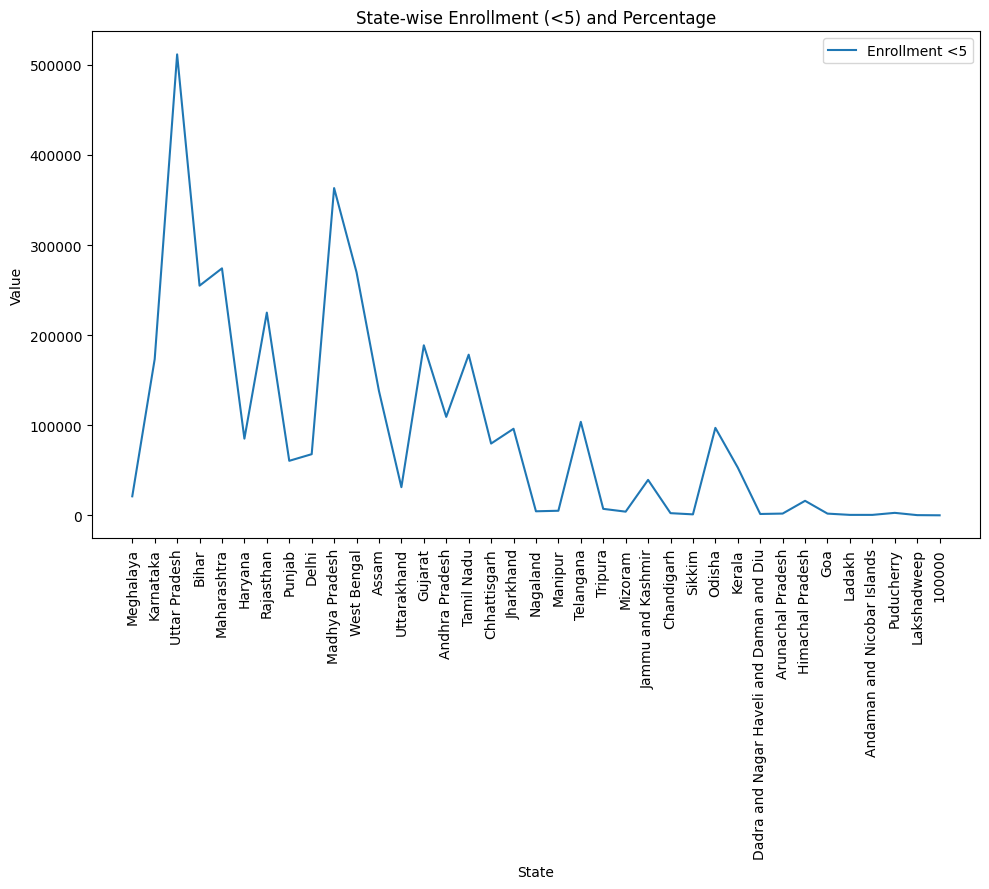

In [ ]:
plt.figure(figsize=(10,9))

plt.plot(Age_less5['State_Name'], Age_less5['Enrollment_less5'], label='Enrollment <5')

plt.title('State-wise Enrollment (<5) and Percentage')
plt.xlabel('State')
plt.ylabel('Value')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


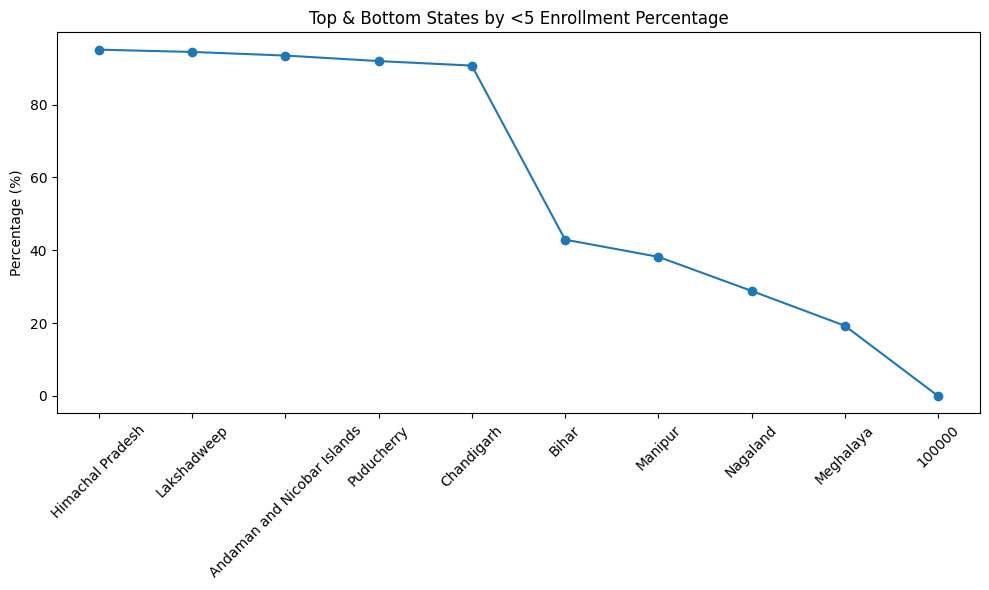

In [ ]:
##Percentage Graph for state enrollment of Age less than 5

focus = Age_less5.sort_values('Percentage', ascending=False)
focus = pd.concat([focus.head(5), focus.tail(5)])

plt.figure(figsize=(10,6))
plt.plot(focus['State_Name'], focus['Percentage'], marker='o')
plt.xticks(rotation=45)
plt.title('Top & Bottom States by <5 Enrollment Percentage')
plt.ylabel('Percentage (%)')
plt.tight_layout()
plt.show()


In [ ]:
states = []
enroll_5_17 = []
percentages = []

for i in state_name:
    val = data[data['state'] == i]['age_5_17'].sum()
    perct = (val / Total_Enroll[i]) * 100

    states.append(i)
    enroll_5_17.append(val)
    percentages.append(perct)

Age_Enroll_5_17 = pd.DataFrame({
    'State_Name': states,
    'Enrollment_5to17': enroll_5_17,
    'Percentage': percentages
})
print('According to Percentage of Enrollment of more than 5 Yrs but less than 17 Yrs in State Ranking is :')
print('\n')
print(Age_Enroll_5_17.sort_values(by='Percentage', ascending=False))
print('\n')
print('According to Number of Enrollment of Enrollment of more than 5 Yrs but less than 17 Yrs in States Ranking is :')
print('\n')
print(Age_Enroll_5_17.sort_values(by='Enrollment_5to17', ascending = False))


According to Percentage of Enrollment of more than 5 Yrs but less than 17 Yrs in State Ranking is :


                                  State_Name  Enrollment_5to17  Percentage
18                                  Nagaland              9856   63.879707
19                                   Manipur              7895   59.815138
3                                      Bihar            327040   55.081256
29                         Arunachal Pradesh              2176   51.320755
0                                  Meghalaya             53089   48.598944
25                                    Sikkim              1030   47.356322
2                              Uttar Pradesh            473160   47.198617
17                                 Jharkhand             56152   36.554436
21                                   Tripura              3597   32.682173
6                                  Rajasthan            110131   32.335264
11                                     Assam             64834   28.76920

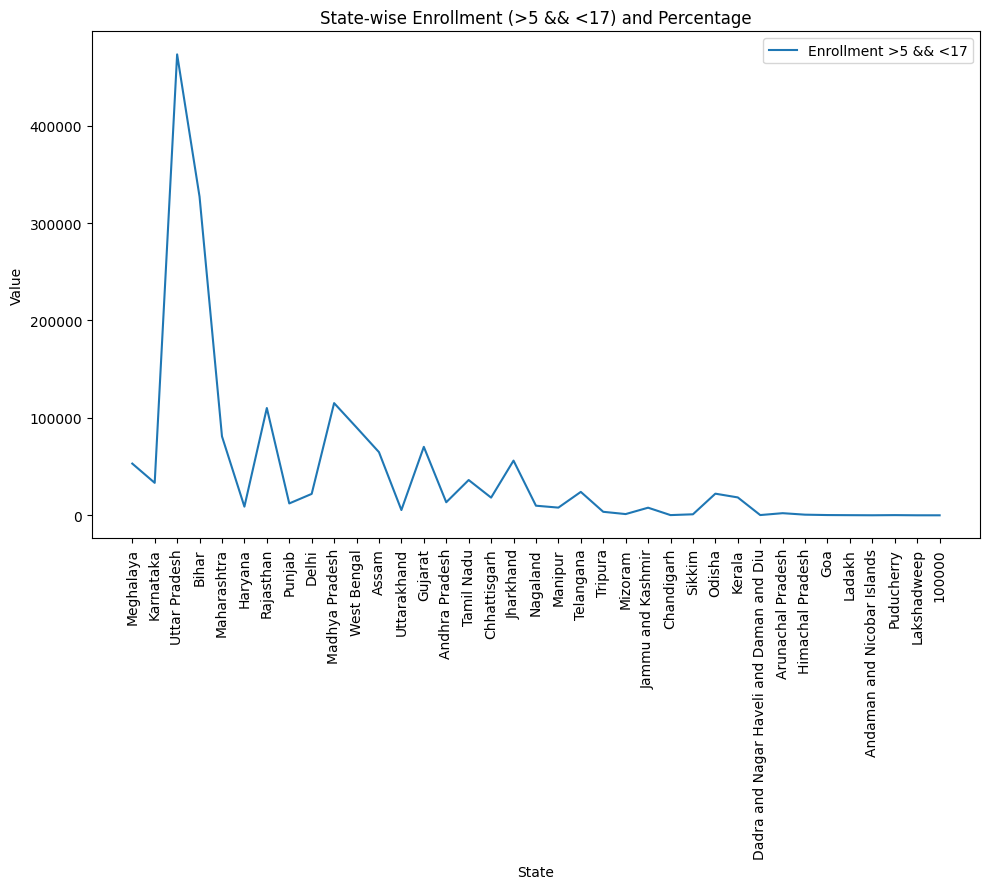

In [ ]:
plt.figure(figsize=(10,9))

plt.plot(Age_Enroll_5_17['State_Name'], Age_Enroll_5_17['Enrollment_5to17'], label='Enrollment >5 && <17')

plt.title('State-wise Enrollment (>5 && <17) and Percentage')
plt.xlabel('State')
plt.ylabel('Value')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

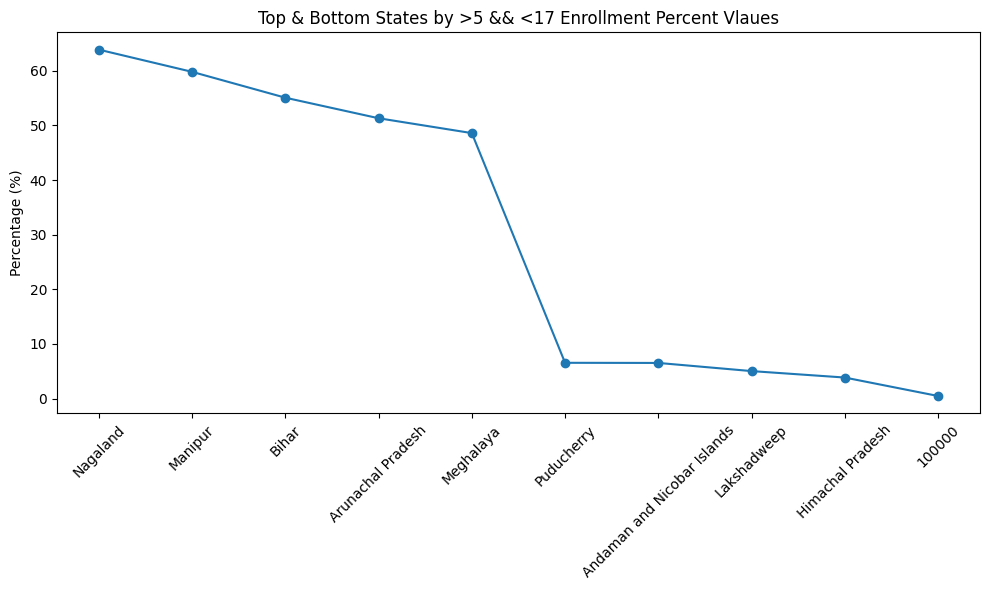

In [ ]:
##Percentage Graph for state enrollment of Age greater than 5 and less than 17

focus = Age_Enroll_5_17.sort_values('Percentage', ascending=False)
focus = pd.concat([focus.head(5), focus.tail(5)])

plt.figure(figsize=(10,6))
plt.plot(focus['State_Name'], focus['Percentage'], marker='o')
plt.xticks(rotation=45)
plt.title('Top & Bottom States by >5 && <17 Enrollment Percent Vlaues')
plt.ylabel('Percentage (%)')
plt.tight_layout()
plt.show()


In [ ]:
states = []
enroll_18_great = []
percentages = []

for i in state_name:
    val = data[data['state'] == i]['age_18_greater'].sum()
    perct = (val / Total_Enroll[i]) * 100

    states.append(i)
    enroll_18_great.append(val)
    percentages.append(perct)

Age_Enroll_18_great = pd.DataFrame({
    'State_Name': states,
    'enroll_18_great': enroll_18_great,
    'Percentage': percentages
})
print('According to Percentage of Enrollment of more than 5 Yrs but less than 17 Yrs in State Ranking is :')
print('\n')
print(Age_Enroll_18_great.sort_values(by='Percentage', ascending=False))
print('\n')
print('According to Number of Enrollment of Enrollment of more than 5 Yrs but less than 17 Yrs in States Ranking is :')
print('\n')
print(Age_Enroll_18_great.sort_values(by='enroll_18_great', ascending = False))

According to Percentage of Enrollment of more than 5 Yrs but less than 17 Yrs in State Ranking is :


                                  State_Name  enroll_18_great  Percentage
36                                    100000              213   99.532710
0                                  Meghalaya            35078   32.111242
11                                     Assam            22555   10.008475
22                                   Mizoram              471    8.157257
18                                  Nagaland             1120    7.259058
31                                       Goa              156    6.842105
13                                   Gujarat            16063    5.840199
25                                    Sikkim              105    4.827586
1                                  Karnataka            10038    4.631975
7                                     Punjab             3117    4.113602
27                                    Kerala             2640    3.569980
29        

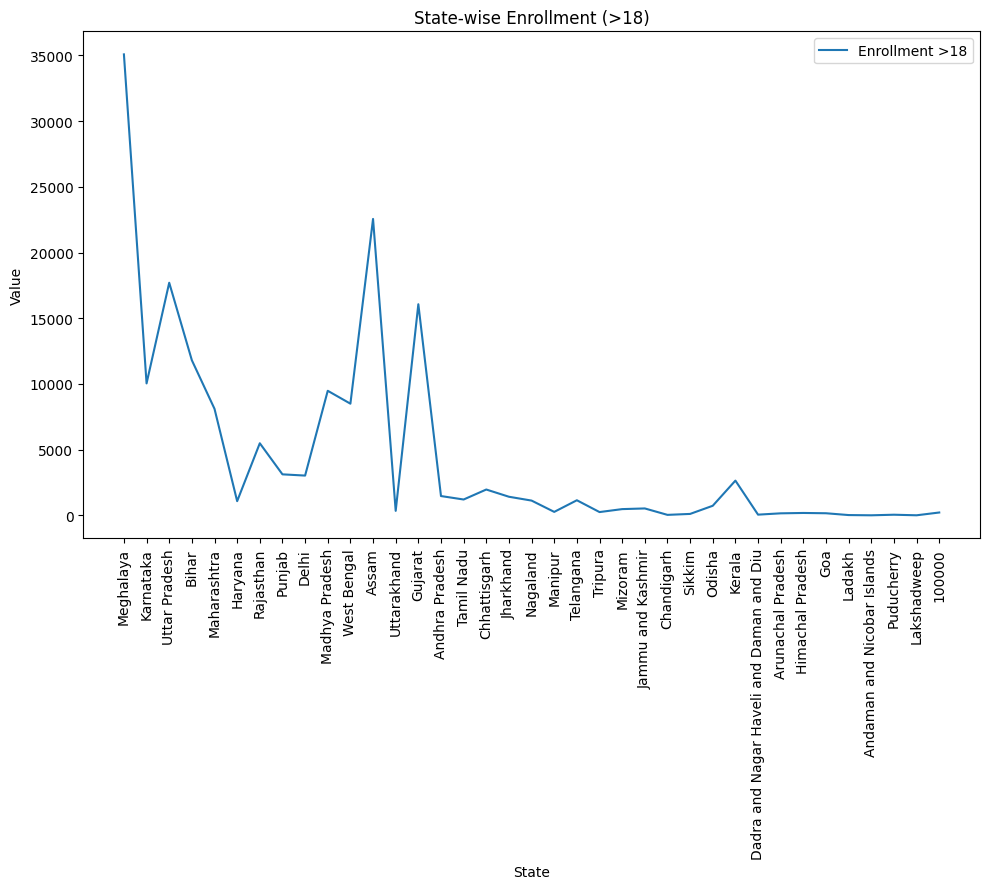

In [ ]:
plt.figure(figsize=(10,9))

plt.plot(Age_Enroll_18_great['State_Name'], Age_Enroll_18_great['enroll_18_great'], label='Enrollment >18')

plt.title('State-wise Enrollment (>18)')
plt.xlabel('State')
plt.ylabel('Value')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

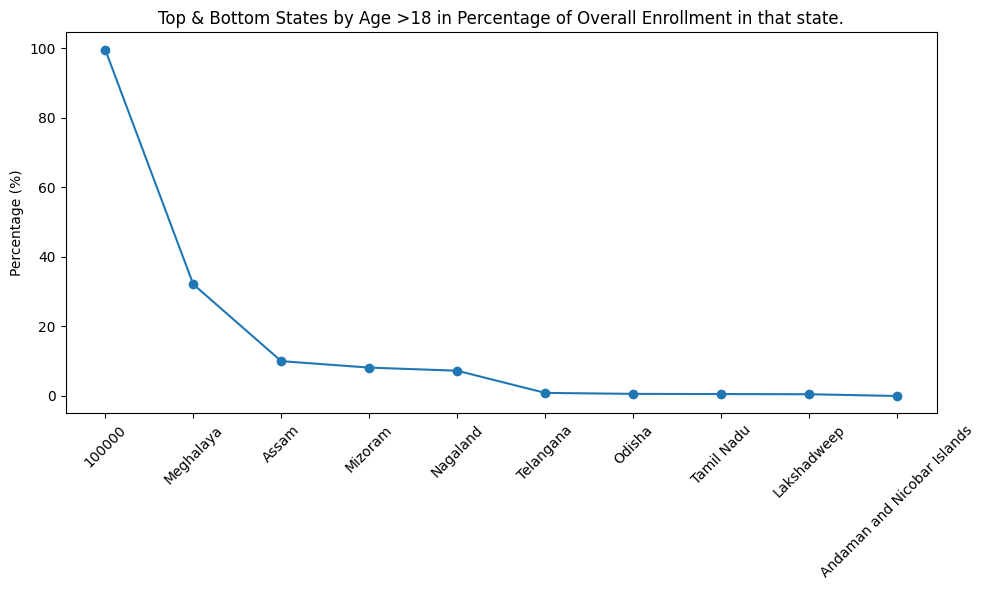

In [ ]:
##Percentage Graph for state enrollment of Age greater than 5 and less than 17

focus = Age_Enroll_18_great.sort_values('Percentage', ascending=False)
focus = pd.concat([focus.head(5), focus.tail(5)])

plt.figure(figsize=(10,6))
plt.plot(focus['State_Name'], focus['Percentage'], marker='o')
plt.xticks(rotation=45)
plt.title('Top & Bottom States by Age >18 in Percentage of Overall Enrollment in that state.')
plt.ylabel('Percentage (%)')
plt.tight_layout()
plt.show()

In [ ]:
data[data['Total_Enrollment'] == 0]

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,Total_Enrollment,day,month


There is not a single day in the given data Where Total Enrollment is zero that means there is no Zero-Enrollment Day in the Dataset.

In [ ]:
data.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,Total_Enrollment,day,month
0,2025-03-02,Meghalaya,East Khasi Hills,793121,11,61,37,109,Sunday,March
1,2025-03-09,Karnataka,Bengaluru Urban,560043,14,33,39,86,Sunday,March
2,2025-03-09,Uttar Pradesh,Kanpur Nagar,208001,29,82,12,123,Sunday,March
3,2025-03-09,Uttar Pradesh,Aligarh,202133,62,29,15,106,Sunday,March
4,2025-03-09,Karnataka,Bengaluru Urban,560016,14,16,21,51,Sunday,March


In [ ]:
data4 = data.groupby(['state','month'])['age_0_5'].sum().reset_index()
data4[data4['age_0_5'] == 0]

,state,month,age_0_5
0,100000,December,0
1,100000,November,0
2,100000,October,0
3,100000,September,0
